# CIE 555 — Grammar Error Correction (GEC) Project

---
## 0 · Global Config & Imports

In [1]:
import os, gc, re, warnings, pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from scipy.sparse import csr_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Choose your load size ───────────────────────────────────────────
LOAD_SIZE = 1_000_000  

# ── Hyper-parameters auto-scaled to LOAD_SIZE ─────────────────────────────────
if LOAD_SIZE <= 50_000:
    BATCH_SIZE        = 128
    BOW_TRAIN         = min(40_000,  LOAD_SIZE)
    BOW_VAL           = min(5_000,   LOAD_SIZE)
    CHUNK_SIZE        = 10_000    
    EVAL_N            = 500        
    INFER_BATCH_SIZE  = 64       
elif LOAD_SIZE <= 100_000:
    BATCH_SIZE        = 128
    BOW_TRAIN         = min(80_000,  LOAD_SIZE)
    BOW_VAL           = min(10_000,  LOAD_SIZE)
    CHUNK_SIZE        = 20_000
    EVAL_N            = 1_000
    INFER_BATCH_SIZE  = 128
else:                               
    BATCH_SIZE        = 64
    BOW_TRAIN         = 200_000
    BOW_VAL           = 20_000
    CHUNK_SIZE        = 50_000
    EVAL_N            = 2_000     
    INFER_BATCH_SIZE  = 256    

VOCAB_SIZE  = 10_000
MAX_LEN_IN  = 50
MAX_LEN_OUT = 50
EMBED_DIM   = 128
LSTM_UNITS  = 256
EPOCHS      = 4
SEED        = 42

DATA_PATH = '/kaggle/input/datasets/abdelhady22/deep-learning-project-1m/cleaned_balanced_dataset.parquet'

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'LOAD_SIZE  : {LOAD_SIZE:,}')
print(f'BATCH_SIZE : {BATCH_SIZE}')
print(f'BOW_TRAIN  : {BOW_TRAIN:,}')
print(f'CHUNK_SIZE : {CHUNK_SIZE:,}')
print(f'TensorFlow : {tf.__version__}')
print(f'GPUs       : {tf.config.list_physical_devices("GPU")}')

2026-05-15 19:31:50.700708: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778873510.886965      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778873510.940483      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778873511.376534      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778873511.376577      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778873511.376580      57 computation_placer.cc:177] computation placer alr

LOAD_SIZE  : 1,000,000
BATCH_SIZE : 64
BOW_TRAIN  : 200,000
CHUNK_SIZE : 50,000
TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 1 · RAM-Safe Data Loading

In [2]:
# Stream only LOAD_SIZE rows — never reads the full file into RAM
pf_chunk  = max(10_000, LOAD_SIZE // 20)   # adaptive batch size for streaming
pf        = pq.ParquetFile(DATA_PATH)
rows_read = 0
chunks    = []

for batch in pf.iter_batches(batch_size=pf_chunk):
    chunks.append(batch.to_pandas())
    rows_read += len(chunks[-1])
    if rows_read >= LOAD_SIZE:
        break

df = pd.concat(chunks, ignore_index=True).iloc[:LOAD_SIZE]
del chunks, pf
gc.collect()

# Clean
df = df[['input_text', 'target_text']].dropna()
df['input_text']  = df['input_text'].astype(str).str.strip()
df['target_text'] = df['target_text'].astype(str).str.strip()
df = df[df['input_text'] != df['target_text']].reset_index(drop=True)

ram_gb = df.memory_usage(deep=True).sum() / 1e9
print(f'Loaded and cleaned : {len(df):,} rows | RAM : {ram_gb:.2f} GB')
df.head(3)

Loaded and cleaned : 999,994 rows | RAM : 0.43 GB


,input_text,target_text
0,We can record the event as it happens for futu...,We can record the event as it happens for use ...
1,The profits policies and techniques of revenue...,Profit policies and techniques of revenue plan...
2,When will theNorthern European airspace be reo...,When will the Northern European airspace be re...


---
## 2 · Exploratory Data Analysis

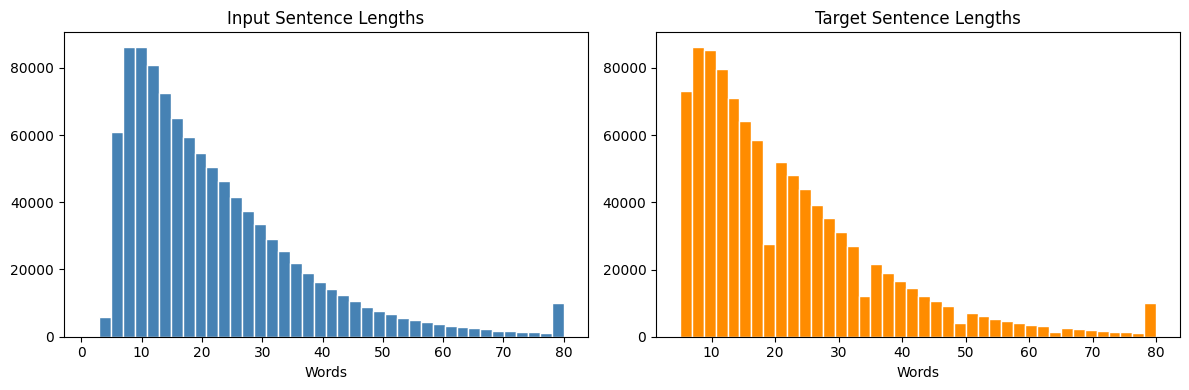

         in_len   out_len
count  999994.0  999994.0
mean       22.1      22.0
std        18.1      15.7
min         1.0       5.0
25%        11.0      11.0
50%        18.0      18.0
75%        29.0      29.0
max      5595.0     149.0

=== Sample GEC Pairs ===
  IN : Walsh started with the first of three half-points through substitute practice and the first with Paul Geaney's five half-frees with 1-2 into 0-0 after passed five minutes.
  OUT: Walsh followed with the first of his three first half points from play and the first of Paul Geaney's five first half frees made it 1-2 to 0-0 after five minutes.

  IN : Dina Hall is a supporting artist of Croaker Percussi Me.
  OUT: Dina Hall is a supporting artist with Croaker Percussion.

  IN : Let it dry, wash of sackcltured, and such the Polishs go on like normal. (We're fans of this 8-free chip-proof nailies that come in four trendy metal shades; $18,. )  < > _ at same time there are work and pictures are there, but it should be acceptable 

In [3]:
df['in_len']  = df['input_text'].str.split().str.len()
df['out_len'] = df['target_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['in_len'].clip(upper=80),  bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Input Sentence Lengths'); axes[0].set_xlabel('Words')
axes[1].hist(df['out_len'].clip(upper=80), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Target Sentence Lengths'); axes[1].set_xlabel('Words')
plt.tight_layout(); plt.show()

print(df[['in_len','out_len']].describe().round(1))
df.drop(columns=['in_len','out_len'], inplace=True)

print('\n=== Sample GEC Pairs ===')
for _, row in df.sample(5, random_state=SEED).iterrows():
    print(f'  IN : {row["input_text"]}')
    print(f'  OUT: {row["target_text"]}')
    print()

---
## 3 · Shared Preprocessing

In [4]:
# ── 3.1  Train / Val / Test split ─────────────────────────────────────────────
train_df, test_df = train_test_split(df, test_size=0.15, random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.12, random_state=SEED)
print(f'Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}')

Train 747,994 | Val 102,000 | Test 150,000


In [5]:
# ── 3.2  Special tokens & TextVectorization ────────────────────────────────────
START_TOKEN = 'starttoken'
END_TOKEN   = 'endtoken'

train_df = train_df.copy()
train_df['target_in']  = START_TOKEN + ' ' + train_df['target_text']
train_df['target_out'] = train_df['target_text'] + ' ' + END_TOKEN

val_df = val_df.copy()
val_df['target_in']  = START_TOKEN + ' ' + val_df['target_text']
val_df['target_out'] = val_df['target_text'] + ' ' + END_TOKEN

# Adapt on all text so special tokens are guaranteed in vocab
all_text = pd.concat([
    train_df['input_text'], train_df['target_text'],
    train_df['target_in'],  train_df['target_out'],
    val_df['input_text'],   val_df['target_text'],
])

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LEN_IN,
    standardize='lower_and_strip_punctuation'
)
vectorizer.adapt(all_text.values)
vocab        = vectorizer.get_vocabulary()
token_to_idx = {t: i for i, t in enumerate(vocab)}
idx_to_token = {i: t for t, i in token_to_idx.items()}

START_IDX = token_to_idx[START_TOKEN]
END_IDX   = token_to_idx[END_TOKEN]
PAD_IDX   = 0
UNK_IDX   = token_to_idx.get('[UNK]', 1)

print(f'Vocab size : {len(vocab):,}')
print(f'START_IDX  : {START_IDX}  → "{vocab[START_IDX]}"')
print(f'END_IDX    : {END_IDX}    → "{vocab[END_IDX]}"')
print(f'UNK_IDX    : {UNK_IDX}    → "{vocab[UNK_IDX]}"')

del all_text
gc.collect()

I0000 00:00:1778873553.001241      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Vocab size : 10,000
START_IDX  : 9  → "starttoken"
END_IDX    : 10    → "endtoken"
UNK_IDX    : 1    → "[UNK]"


36

In [6]:
# 3.3 Vectorisation in chunks — safe for 1M rows without OOM
def vectorize_in_chunks(texts, seq_len=MAX_LEN_IN):
    """
    Vectorise a large Series in chunks of CHUNK_SIZE.
    Safe at 50K, 100K, and 1M — avoids single large tf.constant call.
    """
    v = layers.TextVectorization(
        max_tokens=VOCAB_SIZE,
        output_mode='int',
        output_sequence_length=seq_len,
        standardize='lower_and_strip_punctuation'
    )
    v.set_vocabulary(vocab)
    parts      = []
    texts_list = texts.tolist()
    for start in range(0, len(texts_list), CHUNK_SIZE):
        chunk = texts_list[start:start + CHUNK_SIZE]
        parts.append(v(tf.constant(chunk)).numpy())
        gc.collect()
    return np.concatenate(parts, axis=0)

print('Vectorising encoder inputs …')
X_train_enc = vectorize_in_chunks(train_df['input_text'])
X_val_enc   = vectorize_in_chunks(val_df['input_text'])
X_test_enc  = vectorize_in_chunks(test_df['input_text'])

print('Vectorising decoder inputs / outputs …')
y_train_in  = vectorize_in_chunks(train_df['target_in'],  seq_len=MAX_LEN_OUT)
y_train_out = vectorize_in_chunks(train_df['target_out'], seq_len=MAX_LEN_OUT)
y_val_in    = vectorize_in_chunks(val_df['target_in'],    seq_len=MAX_LEN_OUT)
y_val_out   = vectorize_in_chunks(val_df['target_out'],   seq_len=MAX_LEN_OUT)

y_test_text = test_df['target_text'].values

print(f'X_train_enc : {X_train_enc.shape} | y_train_out : {y_train_out.shape}')

gc.collect()

Vectorising encoder inputs …
Vectorising decoder inputs / outputs …
X_train_enc : (747994, 100) | y_train_out : (747994, 100)


170

---
## 4 · Evaluation Metric

**F0.5** weights precision twice as much as recall — correct for GEC where false corrections are worse than missed errors.

In [7]:
def token_level_metrics(y_true_texts, y_pred_texts):
    
    total_correct = total_pred = total_true = total_match = total_tokens = 0

    for true, pred in zip(y_true_texts, y_pred_texts):
        t_tok = true.strip().split()
        p_tok = pred.strip().split() if pred.strip() else ['']

        min_len = min(len(t_tok), len(p_tok))
        max_len = max(len(t_tok), len(p_tok))
        total_match  += sum(t_tok[i] == p_tok[i] for i in range(min_len))
        total_tokens += max_len

        correct       = sum((Counter(t_tok) & Counter(p_tok)).values())
        total_correct += correct
        total_pred    += len(p_tok)
        total_true    += len(t_tok)

    precision = total_correct / total_pred  if total_pred  > 0 else 0.0
    recall    = total_correct / total_true  if total_true  > 0 else 0.0
    f05       = (1 + 0.5**2) * precision * recall / (0.5**2 * precision + recall + 1e-9)
    accuracy  = total_match  / total_tokens if total_tokens > 0 else 0.0

    return {
        'Accuracy':  round(accuracy,  4),
        'Precision': round(precision, 4),
        'Recall':    round(recall,    4),
        'F0.5':      round(f05,       4)
    }

results_summary = {}
print('Metric function ready.')

Metric function ready.


---
## 5 · Model 1 — Bag of Words Baseline (FNN)

**Architecture:** `BoW vector → Dense(256) → RepeatVector → TimeDistributed Dense(VOCAB_SIZE)`  
Ignores word order — serves as the lower-bound baseline.

In [42]:
# ── 5.1  Build BoW sparse matrices ────────────────────────────────────────────
# Use a subset to avoid OOM — 200k train rows is enough for a baseline
BOW_TRAIN = min(200_000, len(train_df))
BOW_VAL   = min(20_000,  len(val_df))

def texts_to_bow(texts, vocab_size=VOCAB_SIZE):
    """Convert texts to sparse count-vector matrix using the shared vectorizer."""
    seqs = vectorizer(tf.constant(texts.tolist())).numpy()
    rows, cols, data = [], [], []
    for i, seq in enumerate(seqs):
        for idx in seq:
            if 0 < idx < vocab_size:
                rows.append(i)
                cols.append(idx)
                data.append(1)
    return csr_matrix((data, (rows, cols)), shape=(len(texts), vocab_size), dtype=np.float32)

print('Building BoW matrices …')
X_bow_train = texts_to_bow(train_df['input_text'].iloc[:BOW_TRAIN])
X_bow_val   = texts_to_bow(val_df['input_text'].iloc[:BOW_VAL])
y_bow_train = y_train_out[:BOW_TRAIN]   # already vectorised in Section 3
y_bow_val   = y_val_out[:BOW_VAL]
print(f'BoW train: {X_bow_train.shape} | val: {X_bow_val.shape}')

Building BoW matrices …
BoW train: (200000, 10000) | val: (20000, 10000)


In [43]:
# ── 5.2  Build & compile FNN ──────────────────────────────────────────────────
def build_bow_model(vocab_size=VOCAB_SIZE, hidden=256, target_len=MAX_LEN_OUT):
    inp     = keras.Input(shape=(vocab_size,), name='bow_input')
    context = layers.Dense(hidden, activation='relu')(inp)
    context = layers.Dropout(0.3)(context)
    x       = layers.RepeatVector(target_len)(context)
    out     = layers.TimeDistributed(layers.Dense(vocab_size, activation='softmax'))(x)
    return keras.Model(inp, out, name='BoW_FNN')

bow_model = build_bow_model()
bow_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)
bow_model.summary()

Model: "BoW_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bow_input (InputLayer)          │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 50, 10000)      │     2,570,000 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,130,256 (19.57 MB)

 Trainable params: 5,130,256 (19.57 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ── 5.3  Train with sparse generator (avoids dense OOM) ──────────────────────
def sparse_generator(X_sp, y_np, batch_size=512):
    n = X_sp.shape[0]
    while True:
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            b = idx[start:start + batch_size]
            yield X_sp[b].toarray(), y_np[b]

BATCH_BOW   = 512
steps_train = BOW_TRAIN // BATCH_BOW
steps_val   = BOW_VAL   // BATCH_BOW

bow_history = bow_model.fit(
    sparse_generator(X_bow_train, y_bow_train, BATCH_BOW),
    steps_per_epoch  = steps_train,
    validation_data  = sparse_generator(X_bow_val, y_bow_val, BATCH_BOW),
    validation_steps = steps_val,
    epochs           = 5,
    callbacks        = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=1, factor=0.5, verbose=1)
    ]
)

Epoch 1/5


I0000 00:00:1778682339.001834      68 service.cc:152] XLA service 0x7f67ec02dab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778682339.001872      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778682339.955432      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778682355.785368      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


390/390 ━━━━━━━━━━━━━━━━━━━━ 102s 213ms/step - accuracy: 0.5455 - loss: 5.6598 - val_accuracy: 0.5711 - val_loss: 3.2498 - learning_rate: 0.0010
Epoch 2/5
390/390 ━━━━━━━━━━━━━━━━━━━━ 94s 200ms/step - accuracy: 0.5688 - loss: 3.2317 - val_accuracy: 0.5704 - val_loss: 3.0425 - learning_rate: 0.0010
Epoch 3/5
390/390 ━━━━━━━━━━━━━━━━━━━━ 82s 211ms/step - accuracy: 0.5691 - loss: 3.0446 - val_accuracy: 0.5691 - val_loss: 2.9077 - learning_rate: 0.0010
Epoch 4/5
390/390 ━━━━━━━━━━━━━━━━━━━━ 78s 200ms/step - accuracy: 0.5666 - loss: 2.9211 - val_accuracy: 0.5702 - val_loss: 2.7962 - learning_rate: 0.0010
Epoch 5/5
390/390 ━━━━━━━━━━━━━━━━━━━━ 78s 200ms/step - accuracy: 0.5665 - loss: 2.8151 - val_accuracy: 0.5668 - val_loss: 2.7329 - learning_rate: 0.0010


---
## 6 · Model 2 — LSTM Without Attention

**Architecture:** `Embedding → BiLSTM encoder → [h,c] → LSTM decoder (teacher forcing) → Dense`  
The bottleneck: the full input is compressed into one fixed-size hidden state.

In [44]:
# ── 6.1  Build ────────────────────────────────────────────────────────────────
def build_lstm_seq2seq(vocab_size, embed_dim, lstm_units):
    enc_input = keras.Input(shape=(None,), name='enc_input')
    enc_embed = layers.Embedding(vocab_size, embed_dim)(enc_input)
    _, fh, fc, bh, bc = layers.Bidirectional(
        layers.LSTM(lstm_units, return_state=True, return_sequences=False),
        name='enc_bilstm'
    )(enc_embed)
    state_h = layers.Dense(lstm_units, name='state_h')(layers.Concatenate()([fh, bh]))
    state_c = layers.Dense(lstm_units, name='state_c')(layers.Concatenate()([fc, bc]))

    dec_input = keras.Input(shape=(None,), name='dec_input')
    dec_embed = layers.Embedding(vocab_size, embed_dim)(dec_input)
    dec_out   = layers.LSTM(lstm_units, return_sequences=True, return_state=False,
                             name='dec_lstm')(dec_embed, initial_state=[state_h, state_c])
    dec_out   = layers.Dropout(0.2)(dec_out)
    logits    = layers.Dense(vocab_size, activation='softmax', name='output')(dec_out)

    return keras.Model([enc_input, dec_input], logits, name='LSTM_Seq2Seq')

lstm_model = build_lstm_seq2seq(VOCAB_SIZE, EMBED_DIM, LSTM_UNITS)
lstm_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)
lstm_model.summary()

Model: "LSTM_Seq2Seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_input           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, None, 128) │  1,280,000 │ enc_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bilstm          │ [(None, 512),     │    788,480 │ embedding_16[0][… │
│ (Bidirectional)     │ (None, 256),      │            │                   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_input           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 512)       │          0 │ enc_bilstm[0][1], │
│ (Concatenate)       │                   │            │ enc_bilstm[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 512)       │          0 │ enc_bilstm[0][2], │
│ (Concatenate)       │                   │            │ enc_bilstm[0][4]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, None, 128) │  1,280,000 │ dec_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_h (Dense)     │ (None, 256)       │    131,328 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_c (Dense)     │ (None, 256)       │    131,328 │ concatenate_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_lstm (LSTM)     │ (None, None, 256) │    394,240 │ embedding_17[0][… │
│                     │                   │            │ state_h[0][0],    │
│                     │                   │            │ state_c[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_51          │ (None, None, 256) │          0 │ dec_lstm[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, None,      │  2,570,000 │ dropout_51[0][0]  │
│                     │ 10000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,575,376 (25.08 MB)

 Trainable params: 6,575,376 (25.08 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ── 6.2  Train ────────────────────────────────────────────────────────────────
lstm_history = lstm_model.fit(
    [X_train_enc, y_train_in], y_train_out,
    validation_data=([X_val_enc, y_val_in], y_val_out),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint('/kaggle/working/checkpoints/lstm_best.keras',
                                        save_best_only=True)
    ],
    verbose=1
)

Epoch 1/5
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 901s 77ms/step - accuracy: 0.6588 - loss: 2.4362 - val_accuracy: 0.7269 - val_loss: 1.6255
Epoch 2/5
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 886s 76ms/step - accuracy: 0.7308 - loss: 1.5766 - val_accuracy: 0.7645 - val_loss: 1.3018
Epoch 3/5
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 870s 74ms/step - accuracy: 0.7620 - loss: 1.3115 - val_accuracy: 0.7856 - val_loss: 1.1515
Epoch 4/5
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 871s 75ms/step - accuracy: 0.7815 - loss: 1.1767 - val_accuracy: 0.7984 - val_loss: 1.0747
Epoch 5/5
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 866s 74ms/step - accuracy: 0.7937 - loss: 1.1003 - val_accuracy: 0.8069 - val_loss: 1.0293


---
## 7 · Model 3 — LSTM With Bahdanau Attention

**Architecture:** `BiLSTM encoder (return_sequences) → Bahdanau Attention → LSTM decoder`  
At each decoder step the model re-reads all encoder positions — resolves the bottleneck.

In [47]:
# ── 7.1  Bahdanau Attention layer ─────────────────────────────────────────────
class BahdanauAttention(layers.Layer):
    """Additive attention (Bahdanau et al., 2015)."""
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1, self.W2, self.V = layers.Dense(units), layers.Dense(units), layers.Dense(1)
        self.units = units

    def call(self, query, values):
        # query: (B, dec_units)  values: (B, T, enc_units)
        score   = self.V(tf.nn.tanh(self.W1(values) + self.W2(tf.expand_dims(query, 1))))
        alpha   = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(alpha * values, axis=1)
        return context, alpha

    def get_config(self):
        cfg = super().get_config(); cfg['units'] = self.units; return cfg
    print("done")

done


In [104]:
# ── 7.2  LSTMAttentionSeq2Seq model ───────────────────────────────────────────
ATT_UNITS = 128
MAX_LEN_IN  = 100
MAX_LEN_OUT = 100

class LSTMAttentionSeq2Seq(keras.Model):
    def __init__(self, vocab_size, embed_dim, lstm_units, att_units, **kwargs):
        super().__init__(**kwargs)
        self.enc_embedding = layers.Embedding(vocab_size, embed_dim)
        self.dec_embedding = layers.Embedding(vocab_size, embed_dim)
        self.enc_bilstm    = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True, return_state=True),
            name='enc_bilstm_att'
        )
        self.enc_proj      = layers.Dense(lstm_units)
        self.state_h_proj  = layers.Dense(lstm_units)
        self.state_c_proj  = layers.Dense(lstm_units)
        self.attention     = BahdanauAttention(att_units)
        self.dec_lstm      = layers.LSTM(lstm_units, return_state=True)
        self.output_dense  = layers.Dense(vocab_size, activation='softmax')
        self.lstm_units    = lstm_units

    def call(self, inputs, training=False):
        enc_inp, dec_inp = inputs

        enc_emb = self.enc_embedding(enc_inp)
        enc_seq, fh, fc, bh, bc = self.enc_bilstm(enc_emb)
        enc_seq = self.enc_proj(enc_seq)
        sh      = self.state_h_proj(tf.concat([fh, bh], axis=-1))
        sc      = self.state_c_proj(tf.concat([fc, bc], axis=-1))

        dec_emb       = self.dec_embedding(dec_inp)
        # tf.unstack with static num — graph-safe, unlike iterating tf.range
        dec_emb_steps = tf.unstack(dec_emb, num=MAX_LEN_OUT, axis=1)
        outputs       = []
        for token_emb in dec_emb_steps:
            context, _ = self.attention(sh, enc_seq)
            lstm_inp   = tf.concat([tf.expand_dims(token_emb, 1),
                                    tf.expand_dims(context,   1)], axis=-1)
            _, sh, sc  = self.dec_lstm(lstm_inp, initial_state=[sh, sc])
            outputs.append(self.output_dense(sh))

        return tf.stack(outputs, axis=1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'vocab_size': self.enc_embedding.input_dim,
            'embed_dim':  self.enc_embedding.output_dim,
            'lstm_units': self.lstm_units,
            'att_units':  self.attention.units,
        })
        return cfg

    @classmethod
    def from_config(cls, config):
        return cls(**config)

attn_model = LSTMAttentionSeq2Seq(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS, att_units=ATT_UNITS,
    name='LSTM_Attention'
)
attn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)
# Dummy pass to build the model before summary
_ = attn_model([X_train_enc[:2], y_train_in[:2]])
attn_model.summary()

Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_32 (Embedding)        │ (2, 100, 128)          │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_33 (Embedding)        │ (2, 100, 128)          │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bilstm_att (Bidirectional)  │ ((2, 100, 512), (2,    │       788,480 │
│                                 │ 256), (2, 256), (2,    │               │
│                                 │ 256), (2, 256))        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_107 (Dense)               │ (2, 100, 256)          │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_108 (Dense)               │ (2, 256)               │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_109 (Dense)               │ (2, 256)               │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention_9            │ ?                      │        65,921 │
│ (BahdanauAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ ((2, 256), (2, 256),   │       656,384 │
│                                 │ (2, 256))              │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (2, 10000)             │     2,570,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,034,769 (26.84 MB)

 Trainable params: 7,034,769 (26.84 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
print('Starting Attention Model training ...')

attn_history = attn_model.fit(
    [X_train_enc, y_train_in], y_train_out,
    validation_data=([X_val_enc, y_val_in], y_val_out),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=1, factor=0.5, verbose=1),
        keras.callbacks.ModelCheckpoint('/kaggle/working/attn_best.keras',
                                        save_best_only=True,
                                        save_weights_only=False)  # full save enabled by get_config()
    ],
    verbose=1
)

Starting Attention Model training ...
Epoch 1/4
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 1994s 167ms/step - accuracy: 0.7080 - loss: 2.1935 - val_accuracy: 0.8655 - val_loss: 1.0130 - learning_rate: 0.0010
Epoch 2/4
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8144 - loss: 1.3420
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 1922s 164ms/step - accuracy: 0.8144 - loss: 1.3420 - val_accuracy: 0.6386 - val_loss: 2.5851 - learning_rate: 0.0010
Epoch 3/4
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 1923s 165ms/step - accuracy: 0.7995 - loss: 1.4259 - val_accuracy: 0.8788 - val_loss: 0.9239 - learning_rate: 5.0000e-04
Epoch 4/4
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 1943s 166ms/step - accuracy: 0.8771 - loss: 0.9341 - val_accuracy: 0.8818 - val_loss: 0.8973 - learning_rate: 5.0000e-04


---
## 8 · Model 4 — Encoder-Decoder Transformer

**Architecture:** `Positional Embedding → N × EncoderBlock → N × DecoderBlock → Dense`  
Self-attention processes all tokens in parallel — captures global dependencies.

In [49]:
# ── 8.1  Building blocks ───────────────────────────────────────────────────────
def positional_encoding(max_len, d_model):
    pos    = np.arange(max_len)[:, np.newaxis]
    dims   = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dims // 2)) / d_model)
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], tf.float32)

class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, vocab_size, max_len, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_enc   = positional_encoding(max_len, embed_dim)
        self.embed_dim = embed_dim

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return (self.token_emb(x) * tf.math.sqrt(tf.cast(self.embed_dim, tf.float32))
                + self.pos_enc[:, :seq_len, :])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'vocab_size': self.token_emb.input_dim,
                    'max_len':    self.pos_enc.shape[1],
                    'embed_dim':  self.embed_dim})
        return cfg

class TransformerEncoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha   = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn   = keras.Sequential([layers.Dense(ff_dim, activation='relu'), layers.Dense(embed_dim)])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        x = self.norm1(x + self.drop1(self.mha(x, x, training=training), training=training))
        return self.norm2(x + self.drop2(self.ffn(x), training=training))

class TransformerDecoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha1  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.mha2  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn   = keras.Sequential([layers.Dense(ff_dim, activation='relu'), layers.Dense(embed_dim)])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)
        self.drop3 = layers.Dropout(dropout)

    def call(self, x, enc_output, training=False):
        x = self.norm1(x + self.drop1(self.mha1(x, x, use_causal_mask=True, training=training), training=training))
        x = self.norm2(x + self.drop2(self.mha2(x, enc_output, training=training), training=training))
        return self.norm3(x + self.drop3(self.ffn(x), training=training))

print('Transformer blocks defined ✓')

Transformer blocks defined ✓


In [50]:
# ── 8.2  Build & compile Transformer ──────────────────────────────────────────
NUM_HEADS  = 4
NUM_LAYERS = 2
FF_DIM     = 256
TF_EMBED   = 128
DROPOUT    = 0.1

def build_transformer(vocab_size, max_len_in, max_len_out,
                       embed_dim, num_heads, num_layers, ff_dim, dropout):
    enc_inp = keras.Input(shape=(max_len_in,),  name='enc_inp')
    dec_inp = keras.Input(shape=(max_len_out,), name='dec_inp')
    enc_x   = TokenAndPositionEmbedding(vocab_size, max_len_in,  embed_dim)(enc_inp)
    dec_x   = TokenAndPositionEmbedding(vocab_size, max_len_out, embed_dim)(dec_inp)
    for i in range(num_layers):
        enc_x = TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout, name=f'enc_block_{i}')(enc_x)
    for i in range(num_layers):
        dec_x = TransformerDecoderBlock(embed_dim, num_heads, ff_dim, dropout, name=f'dec_block_{i}')(dec_x, enc_x)
    out = layers.Dense(vocab_size, activation='softmax', name='lm_head')(dec_x)
    return keras.Model([enc_inp, dec_inp], out, name='Transformer_GEC')

class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(
            tf.math.rsqrt(step), step * (self.warmup_steps ** -1.5)
        )
    def get_config(self):
        return {
            "d_model": int(self.d_model.numpy()),
            "warmup_steps": self.warmup_steps
        }

transformer_model = build_transformer(
    vocab_size=VOCAB_SIZE, max_len_in=MAX_LEN_IN, max_len_out=MAX_LEN_OUT,
    embed_dim=TF_EMBED, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    ff_dim=FF_DIM, dropout=DROPOUT
)
transformer_model.compile(
    optimizer=keras.optimizers.Adam(WarmupSchedule(TF_EMBED), beta_1=0.9, beta_2=0.98, epsilon=1e-9),
    loss='sparse_categorical_crossentropy',
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
)
transformer_model.summary()

Model: "Transformer_GEC"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_inp             │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 50, 128)   │  1,280,000 │ enc_inp[0][0]     │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_inp             │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block_0         │ (None, 50, 128)   │    132,480 │ token_and_positi… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, 50, 128)   │  1,280,000 │ dec_inp[0][0]     │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_block_1         │ (None, 50, 128)   │    132,480 │ enc_block_0[0][0] │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_block_0         │ (None, 50, 128)   │    198,784 │ token_and_positi… │
│ (TransformerDecode… │                   │            │ enc_block_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_block_1         │ (None, 50, 128)   │    198,784 │ dec_block_0[0][0… │
│ (TransformerDecode… │                   │            │ enc_block_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lm_head (Dense)     │ (None, 50, 10000) │  1,290,000 │ dec_block_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,512,528 (17.21 MB)

 Trainable params: 4,512,528 (17.21 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ── 8.3  Train ────────────────────────────────────────────────────────────────
tf_history = transformer_model.fit(
    [X_train_enc, y_train_in], y_train_out,
    validation_data=([X_val_enc, y_val_in], y_val_out),
    epochs=10,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=2,
            restore_best_weights=True,
            monitor='val_loss'
        ),

        keras.callbacks.ModelCheckpoint(
            '/kaggle/working/checkpoints/transformer_best.keras',
            save_best_only=True,
            save_weights_only=False
        )
    ],
    verbose=1
)

Epoch 1/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 312s 25ms/step - accuracy: 0.7619 - loss: 2.2651 - val_accuracy: 0.9205 - val_loss: 0.5463
Epoch 2/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 273s 23ms/step - accuracy: 0.9189 - loss: 0.5451 - val_accuracy: 0.9235 - val_loss: 0.5114
Epoch 3/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 273s 23ms/step - accuracy: 0.9222 - loss: 0.5072 - val_accuracy: 0.9245 - val_loss: 0.4997
Epoch 4/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 273s 23ms/step - accuracy: 0.9238 - loss: 0.4898 - val_accuracy: 0.9248 - val_loss: 0.4938
Epoch 5/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 273s 23ms/step - accuracy: 0.9248 - loss: 0.4788 - val_accuracy: 0.9252 - val_loss: 0.4896
Epoch 6/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 273s 23ms/step - accuracy: 0.9255 - loss: 0.4710 - val_accuracy: 0.9253 - val_loss: 0.4871
Epoch 7/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 273s 23ms/step - accuracy: 0.9260 - loss: 0.4652 - val_accuracy: 0.9254 - val_loss: 0.4864
Epoch 8/10
11688/11688 ━━━━━━━━━━━━━━━━━━━━ 273s 23ms/s

---
## 9 · Linguistic Analysis

In [ ]:
def fallback_to_input(inputs, preds, min_words=2):
    fixed = []
    for inp, pred in zip(inputs, preds):
        if not isinstance(pred, str) or not pred.strip() or len(pred.split()) < min_words:
            fixed.append(inp)
        else:
            fixed.append(pred)
    return fixed


In [88]:
MAX_LEN_IN = 50
MAX_LEN_OUT = 50
# ── BoW Inference & Evaluation ──────────────────────────────────────────
# EVAL_N is set in Section 0 (auto-scales with LOAD_SIZE)
EVAL_N = min(EVAL_N, len(X_test_enc))

X_bow_test     = texts_to_bow(test_df['input_text'].iloc[:EVAL_N])
# Predict in chunks to avoid OOM
CHUNK_SIZE = 200

bow_preds_list = []

for i in range(0, X_bow_test.shape[0], CHUNK_SIZE):
    X_chunk = X_bow_test[i:i+CHUNK_SIZE].toarray()

    preds = bow_model.predict(
        X_chunk,
        batch_size=64,
        verbose=0
    )

    bow_preds_list.append(preds)

    del X_chunk, preds
    gc.collect()

bow_preds_prob = np.concatenate(bow_preds_list, axis=0)
def bow_decode(prob_matrix, top_k=MAX_LEN_OUT, min_len=3):
    """Decode BoW outputs while blocking bad special tokens."""
    sentences = []

    for seq_probs in prob_matrix:   # (MAX_LEN_OUT, vocab)
        words = []

        for step, step_probs in enumerate(seq_probs):
            step_probs = step_probs.copy()

            # Never allow these tokens to be generated
            step_probs[PAD_IDX] = -1e9
            step_probs[START_IDX] = -1e9
            step_probs[UNK_IDX] = -1e9

            # Prevent ending too early
            if step < min_len:
                step_probs[END_IDX] = -1e9

            tok = int(np.argmax(step_probs))

            if tok == END_IDX:
                break

            word = idx_to_token.get(tok, '')
            if word:
                words.append(word)

        sentences.append(' '.join(words))

    return sentences


bow_pred_texts = bow_decode(bow_preds_prob)
bow_pred_texts = fallback_to_input(
    test_df['input_text'].iloc[:EVAL_N].tolist(),
    bow_pred_texts
)

results_summary['BoW Baseline'] = token_level_metrics(y_test_text[:EVAL_N], bow_pred_texts)
print('BoW Baseline:', results_summary['BoW Baseline'])

def predict_bow_sentences(sentences):
    X_bow = texts_to_bow(pd.Series(sentences))
    bow_prob = bow_model.predict(X_bow.toarray(), batch_size=32, verbose=0)
    preds = bow_decode(bow_prob)
    preds = fallback_to_input(sentences, preds)

    print('\n' + '=' * 75)
    print(f'{"Input":<42} | {"BoW Output"}')
    print('=' * 75)
    for inp, pred in zip(sentences, preds):
        print(f'{inp:<42} | {pred}')
    print('=' * 75)

    return preds
predict_bow_sentences([
    "She go to school yesterday",
    "He have a car",
    "I am agree with you"
])


gc.collect()

BoW Baseline: {'Accuracy': 0.035, 'Precision': 0.0495, 'Recall': 0.0682, 'F0.5': 0.0523}


0

In [89]:
MAX_LEN_IN = 50
MAX_LEN_OUT = 50
# ── LSTM no ATT Inference — separate encoder + one-step decoder sub-models ───────────
# Find Embedding layers by type (index-independent and safe)
embedding_layers = [l for l in lstm_model.layers if isinstance(l, layers.Embedding)]
enc_embed_layer  = embedding_layers[0]
dec_embed_layer  = embedding_layers[1]
enc_bilstm_layer = lstm_model.get_layer('enc_bilstm')
state_h_layer    = lstm_model.get_layer('state_h')
state_c_layer    = lstm_model.get_layer('state_c')
dec_lstm_layer   = lstm_model.get_layer('dec_lstm')
output_dense     = lstm_model.get_layer('output')

# Encoder sub-model: fresh Input → same trained layers → states
enc_inf_input               = keras.Input(shape=(MAX_LEN_IN,), dtype='int32', name='enc_inf_input')
enc_emb_out                 = enc_embed_layer(enc_inf_input)
_, fh, fc, bh, bc           = enc_bilstm_layer(enc_emb_out)
inf_sh = state_h_layer(layers.Concatenate()([fh, bh]))
inf_sc = state_c_layer(layers.Concatenate()([fc, bc]))
encoder_inf = keras.Model(enc_inf_input, [inf_sh, inf_sc], name='encoder_inf')

# Decoder sub-model: new LSTM with return_state=True, weights copied from trained
inf_dec_lstm = layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name='inf_dec_lstm')
dec_inf_tok  = keras.Input(shape=(1,),          dtype='int32', name='dec_inf_tok')
dec_inf_h    = keras.Input(shape=(LSTM_UNITS,),               name='dec_inf_h')
dec_inf_c    = keras.Input(shape=(LSTM_UNITS,),               name='dec_inf_c')
dec_emb_out_inf           = dec_embed_layer(dec_inf_tok)
dec_seq_out, out_h, out_c = inf_dec_lstm(dec_emb_out_inf, initial_state=[dec_inf_h, dec_inf_c])
dec_logits_inf            = output_dense(dec_seq_out)
decoder_inf = keras.Model([dec_inf_tok, dec_inf_h, dec_inf_c],
                           [dec_logits_inf, out_h, out_c], name='decoder_inf')

# Build inf_dec_lstm weights via dummy pass, then copy from trained layer
_ = decoder_inf([np.zeros((1,1), dtype='int32'), np.zeros((1, LSTM_UNITS)), np.zeros((1, LSTM_UNITS))])
inf_dec_lstm.set_weights(dec_lstm_layer.get_weights())
print('Encoder/Decoder inference models built ✓')

# tf.function wrappers — eliminates per-call Python/GPU overhead
@tf.function(input_signature=[tf.TensorSpec(shape=[None, MAX_LEN_IN], dtype=tf.int32)])
def encode_lstm(src):
    return encoder_inf(src, training=False)

@tf.function(input_signature=[
    tf.TensorSpec(shape=[None, 1],          dtype=tf.int32),
    tf.TensorSpec(shape=[None, LSTM_UNITS], dtype=tf.float32),
    tf.TensorSpec(shape=[None, LSTM_UNITS], dtype=tf.float32),
])
def decode_step_lstm(tok, h, c):
    return decoder_inf([tok, h, c], training=False)

def greedy_decode_lstm(src_seqs, max_len=MAX_LEN_OUT, min_len=3):
    """Batched greedy decoding with blocked bad tokens."""
    h, c    = encode_lstm(tf.cast(src_seqs, tf.int32))
    N       = len(src_seqs)
    toks    = tf.cast(tf.fill([N, 1], START_IDX), tf.int32)
    done_np = np.zeros(N, dtype=bool)
    results = [[] for _ in range(N)]
    recent  = [[] for _ in range(N)]

    for step in range(max_len):
        logits, h, c = decode_step_lstm(toks, h, c)
        logits_np = logits[:, 0, :].numpy()

        logits_np[:, PAD_IDX] = -1e9
        logits_np[:, START_IDX] = -1e9
        logits_np[:, UNK_IDX] = -1e9

        if step < min_len:
            logits_np[:, END_IDX] = -1e9

        next_toks_np = np.argmax(logits_np, axis=-1)

        for i in np.where(~done_np)[0]:
            tok_i = int(next_toks_np[i])

            if tok_i == END_IDX:
                done_np[i] = True
                continue

            word = idx_to_token.get(tok_i, '')
            if not word:
                continue

            recent[i].append(tok_i)
            if len(recent[i]) >= 3 and len(set(recent[i][-3:])) == 1:
                done_np[i] = True
                continue

            results[i].append(word)

        if done_np.all():
            break

        toks = tf.cast(tf.reshape(next_toks_np, [N, 1]), tf.int32)

    return [' '.join(w) for w in results]

# Evaluate
lstm_preds = greedy_decode_lstm(X_test_enc[:EVAL_N])
lstm_preds = fallback_to_input(
    test_df['input_text'].iloc[:EVAL_N].tolist(),
    lstm_preds
)

results_summary['LSTM (no attn)'] = token_level_metrics(y_test_text[:EVAL_N], lstm_preds)
print('LSTM (no attn):', results_summary['LSTM (no attn)'])

print('\n=== Sample Predictions ===')
for i in range(3):
    print(f'INPUT : {test_df["input_text"].values[i]}')
    print(f'TRUE  : {y_test_text[i]}')
    print(f'PRED  : {lstm_preds[i] or "<<EMPTY>>"}')
    print()

gc.collect()

Encoder/Decoder inference models built ✓
LSTM (no attn): {'Accuracy': 0.1098, 'Precision': 0.3364, 'Recall': 0.3302, 'F0.5': 0.3351}

=== Sample Predictions ===
INPUT : Walsh started with the first of three half-points through substitute practice and the first with Paul Geaney's five half-frees with 1-2 into 0-0 after passed five minutes.
TRUE  : Walsh followed with the first of his three first half points from play and the first of Paul Geaney's five first half frees made it 1-2 to 0-0 after five minutes.
PRED  : the first started with the first three of the following the practice and the first of the first three weeks of a single victory in 12 minutes to five

INPUT : Dina Hall is a supporting artist of Croaker Percussi Me.
TRUE  : Dina Hall is a supporting artist with Croaker Percussion.
PRED  : the hall is a dedicated artist of the us

INPUT : Let it dry, wash of sackcltured, and such the Polishs go on like normal. (We're fans of this 8-free chip-proof nailies that come in four tre

2790

In [90]:
MAX_LEN_IN = 50
MAX_LEN_OUT = 50
# ── 7.4  Inference — separate encoder + one-step decoder sub-models ───────────
# Cannot call the full model with 1 token — tf.unstack expects MAX_LEN_OUT tokens.
# Solution: extract sub-models that accept exactly 1 token per step.

# Encoder sub-model
enc_attn_input = keras.Input(shape=(MAX_LEN_IN,), dtype='int32', name='enc_attn_input')
enc_attn_emb   = attn_model.enc_embedding(enc_attn_input)
enc_attn_seq, fh, fc, bh, bc = attn_model.enc_bilstm(enc_attn_emb)
enc_attn_seq   = attn_model.enc_proj(enc_attn_seq)
# Use layers.Concatenate() — tf.concat is forbidden on KerasTensors
attn_sh = attn_model.state_h_proj(layers.Concatenate()([fh, bh]))
attn_sc = attn_model.state_c_proj(layers.Concatenate()([fc, bc]))
encoder_attn_inf = keras.Model(enc_attn_input, [enc_attn_seq, attn_sh, attn_sc],
                                name='encoder_attn_inf')

# One-step decoder sub-model
dec_attn_tok    = keras.Input(shape=(1,),                      dtype='int32', name='dec_attn_tok')
dec_attn_encseq = keras.Input(shape=(MAX_LEN_IN, LSTM_UNITS),                 name='dec_attn_encseq')
dec_attn_h      = keras.Input(shape=(LSTM_UNITS,),                            name='dec_attn_h')
dec_attn_c      = keras.Input(shape=(LSTM_UNITS,),                            name='dec_attn_c')

tok_emb    = attn_model.dec_embedding(dec_attn_tok)
tok_emb_sq = layers.Lambda(lambda x: tf.squeeze(x, axis=1))(tok_emb)
context, _ = attn_model.attention(dec_attn_h, dec_attn_encseq)
tok_exp    = layers.Lambda(lambda x: tf.expand_dims(x, 1))(tok_emb_sq)
ctx_exp    = layers.Lambda(lambda x: tf.expand_dims(x, 1))(context)
lstm_inp   = layers.Concatenate(axis=-1)([tok_exp, ctx_exp])
_, new_h, new_c = attn_model.dec_lstm(lstm_inp, initial_state=[dec_attn_h, dec_attn_c])
logits_step     = attn_model.output_dense(new_h)
decoder_attn_inf = keras.Model(
    [dec_attn_tok, dec_attn_encseq, dec_attn_h, dec_attn_c],
    [logits_step, new_h, new_c], name='decoder_attn_inf'
)
print('Attention inference models built ✓')

# tf.function wrappers
@tf.function(input_signature=[tf.TensorSpec(shape=[None, MAX_LEN_IN], dtype=tf.int32)])
def encode_attn(src):
    return encoder_attn_inf(src, training=False)

@tf.function(input_signature=[
    tf.TensorSpec(shape=[None, 1],                      dtype=tf.int32),
    tf.TensorSpec(shape=[None, MAX_LEN_IN, LSTM_UNITS], dtype=tf.float32),
    tf.TensorSpec(shape=[None, LSTM_UNITS],             dtype=tf.float32),
    tf.TensorSpec(shape=[None, LSTM_UNITS],             dtype=tf.float32),
])
def decode_step_attn(tok, enc_seq, h, c):
    return decoder_attn_inf([tok, enc_seq, h, c], training=False)

def greedy_decode_attn(src_seqs, max_len=MAX_LEN_OUT, min_len=3):
    enc_seq_all, h, c = encode_attn(tf.cast(src_seqs, tf.int32))
    N       = len(src_seqs)
    toks    = tf.cast(tf.fill([N, 1], START_IDX), tf.int32)
    done_np = np.zeros(N, dtype=bool)
    results = [[] for _ in range(N)]
    recent  = [[] for _ in range(N)]

    for step in range(max_len):
        logits, h, c = decode_step_attn(toks, enc_seq_all, h, c)
        logits_np = logits.numpy()

        logits_np[:, PAD_IDX] = -1e9
        logits_np[:, START_IDX] = -1e9
        logits_np[:, UNK_IDX] = -1e9

        if step < min_len:
            logits_np[:, END_IDX] = -1e9

        next_toks_np = np.argmax(logits_np, axis=-1)

        for i in np.where(~done_np)[0]:
            tok_i = int(next_toks_np[i])

            if tok_i == END_IDX:
                done_np[i] = True
                continue

            word = idx_to_token.get(tok_i, '')
            if not word:
                continue

            recent[i].append(tok_i)
            if len(recent[i]) >= 3 and len(set(recent[i][-3:])) == 1:
                done_np[i] = True
                continue

            results[i].append(word)

        if done_np.all():
            break

        toks = tf.cast(tf.reshape(next_toks_np, [N, 1]), tf.int32)

    return [' '.join(w) for w in results]

# Evaluate
attn_preds = greedy_decode_attn(X_test_enc[:EVAL_N])
attn_preds = fallback_to_input(
    test_df['input_text'].iloc[:EVAL_N].tolist(),
    attn_preds
)

results_summary['LSTM + Attention'] = token_level_metrics(y_test_text[:EVAL_N], attn_preds)
print('LSTM + Attention:', results_summary['LSTM + Attention'])

print('\n=== Sample Predictions (LSTM + Attention) ===')
for i in range(3):
    print(f'INPUT : {test_df["input_text"].values[i]}')
    print(f'TRUE  : {y_test_text[i]}')
    print(f'PRED  : {attn_preds[i] or "<<EMPTY>>"}')
    print()

gc.collect()

Attention inference models built ✓
LSTM + Attention: {'Accuracy': 0.1632, 'Precision': 0.4543, 'Recall': 0.4354, 'F0.5': 0.4504}

=== Sample Predictions (LSTM + Attention) ===
INPUT : Walsh started with the first of three half-points through substitute practice and the first with Paul Geaney's five half-frees with 1-2 into 0-0 after passed five minutes.
TRUE  : Walsh followed with the first of his three first half points from play and the first of Paul Geaney's five first half frees made it 1-2 to 0-0 after five minutes.
PRED  : the last year on the first of three of the first practice through the first with paul and five years five of the following after a total after the country as a total after the country

INPUT : Dina Hall is a supporting artist of Croaker Percussi Me.
TRUE  : Dina Hall is a supporting artist with Croaker Percussion.
PRED  : the mount hall is a memorial artist of the first of me

INPUT : Let it dry, wash of sackcltured, and such the Polishs go on like normal. (We'

3268

In [92]:
MAX_LEN_IN = 50
MAX_LEN_OUT = 50
X_test_enc = X_test_enc[:, :50]
# ── 8.4  Greedy Inference (Transformer) — batched ────────────────────────────
@tf.function(input_signature=[
    tf.TensorSpec(shape=[None, MAX_LEN_IN],  dtype=tf.int32),
    tf.TensorSpec(shape=[None, MAX_LEN_OUT], dtype=tf.int32),
])
def transformer_forward(src, dec_seq):
    """Single batched forward pass through the transformer."""
    return transformer_model([src, dec_seq], training=False)

def greedy_decode_transformer(src_seqs, max_len=MAX_LEN_OUT,
                              batch_size=INFER_BATCH_SIZE, min_len=3):
    """Batched autoregressive greedy decoding with blocked bad tokens."""
    N       = len(src_seqs)
    results = [[] for _ in range(N)]
    recent  = [[] for _ in range(N)]
    done_np = np.zeros(N, dtype=bool)

    for batch_start in range(0, N, batch_size):
        batch_end = min(batch_start + batch_size, N)
        batch_src = src_seqs[batch_start:batch_end]
        B         = len(batch_src)

        dec_arr = np.full((B, MAX_LEN_OUT), PAD_IDX, dtype=np.int32)
        dec_arr[:, 0] = START_IDX
        dec_len = np.ones(B, dtype=np.int32)
        b_done  = np.zeros(B, dtype=bool)

        for step in range(max_len - 1):
            logits = transformer_forward(
                tf.cast(batch_src, tf.int32),
                tf.cast(dec_arr, tf.int32)
            )

            step_logits = tf.gather_nd(
                logits,
                tf.stack([tf.range(B), dec_len - 1], axis=1)
            ).numpy()

            # Block bad tokens
            step_logits[:, PAD_IDX] = -1e9
            step_logits[:, START_IDX] = -1e9
            step_logits[:, UNK_IDX] = -1e9

            if step < min_len:
                step_logits[:, END_IDX] = -1e9

            next_toks_np = np.argmax(step_logits, axis=-1)

            all_done = True
            for j in range(B):
                gi = batch_start + j
                if b_done[j]:
                    continue

                tok = int(next_toks_np[j])

                if tok == END_IDX:
                    b_done[j] = True
                    done_np[gi] = True
                    continue

                word = idx_to_token.get(tok, '')
                if word:
                    recent[gi].append(tok)

                    if len(recent[gi]) >= 3 and len(set(recent[gi][-3:])) == 1:
                        b_done[j] = True
                        done_np[gi] = True
                        continue

                    results[gi].append(word)

                pos = int(dec_len[j])
                if pos < MAX_LEN_OUT:
                    dec_arr[j, pos] = tok
                    dec_len[j] += 1
                else:
                    b_done[j] = True
                    done_np[gi] = True
                    continue

                all_done = False

            if all_done or b_done.all():
                break

    return [' '.join(w) for w in results]

tf_preds = greedy_decode_transformer(X_test_enc[:EVAL_N])
tf_preds = fallback_to_input(
    test_df['input_text'].iloc[:EVAL_N].tolist(),
    tf_preds
)

results_summary['Transformer'] = token_level_metrics(y_test_text[:EVAL_N], tf_preds)
print('Transformer:', results_summary['Transformer'])

print('\n=== Sample Predictions (Transformer) ===')
for i in range(3):
    print(f'INPUT : {test_df["input_text"].values[i]}')
    print(f'TRUE  : {y_test_text[i]}')
    print(f'PRED  : {tf_preds[i] or "<<EMPTY>>"}')
    print()

gc.collect()

Transformer: {'Accuracy': 0.2116, 'Precision': 0.5612, 'Recall': 0.5245, 'F0.5': 0.5535}

=== Sample Predictions (Transformer) ===
INPUT : Walsh started with the first of three half-points through substitute practice and the first with Paul Geaney's five half-frees with 1-2 into 0-0 after passed five minutes.
TRUE  : Walsh followed with the first of his three first half points from play and the first of Paul Geaney's five first half frees made it 1-2 to 0-0 after five minutes.
PRED  : the first started with the first of three months through substitute practice and the first with paul five minutes with 12 to 00 after passed five minutes

INPUT : Dina Hall is a supporting artist of Croaker Percussi Me.
TRUE  : Dina Hall is a supporting artist with Croaker Percussion.
PRED  : the hall is a supporting artist of the year

INPUT : Let it dry, wash of sackcltured, and such the Polishs go on like normal. (We're fans of this 8-free chip-proof nailies that come in four trendy metal shades; $18,.

4936

In [93]:
# ── 9.1  Results Table ────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_summary).T[['Accuracy', 'Precision', 'Recall', 'F0.5']]
results_df.index.name = 'Model'
print('=' * 60)
print(results_df.to_string())
print('=' * 60)

                  Accuracy  Precision  Recall    F0.5
Model                                                
BoW Baseline        0.0350     0.0495  0.0682  0.0523
LSTM (no attn)      0.1098     0.3364  0.3302  0.3351
LSTM + Attention    0.1632     0.4543  0.4354  0.4504
Transformer         0.2116     0.5612  0.5245  0.5535


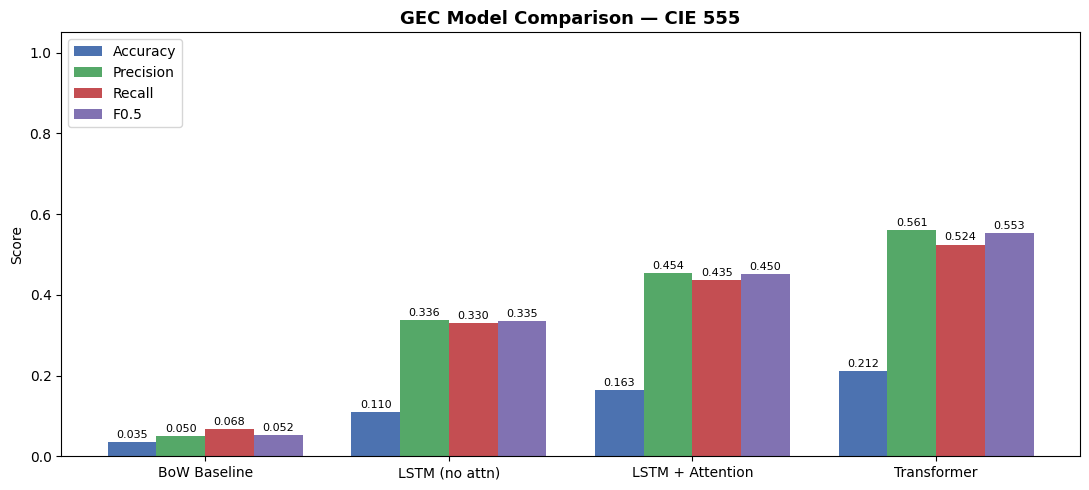

In [94]:
# ── 9.2  Bar Chart ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x, width = np.arange(len(results_df)), 0.2
colors   = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for j, col in enumerate(results_df.columns):
    bars = ax.bar(x + j * width, results_df[col], width, label=col, color=colors[j])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('GEC Model Comparison — CIE 555', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150)
plt.show()

---
## 11 · Dataset Noise Analysis (C4)

In [96]:
# ── 11.1  Noise heuristics ────────────────────────────────────────────────────
slang_pattern  = re.compile(r'\b(u|r|ur|lol|omg|gonna|wanna|idk|tbh|btw|smh)\b', re.I)
fragment_check = lambda s: len(s.split()) < 4

df['has_slang']   = df['input_text'].str.contains(slang_pattern)
df['is_fragment'] = df['input_text'].apply(fragment_check)

print('=== C4 Subset Noise Report ===')
print(f'  Slang/Colloquialisms : {df["has_slang"].mean() * 100:.2f}%')
print(f'  Fragments (<4 words) : {df["is_fragment"].mean() * 100:.2f}%')

print('\n--- Slang examples ---')
for _, row in df[df['has_slang']].head(3).iterrows():
    print(f'  IN : {row["input_text"]}')
    print(f'  OUT: {row["target_text"]}')
    print()

df.drop(columns=['has_slang', 'is_fragment'], inplace=True)
gc.collect()

=== C4 Subset Noise Report ===
  Slang/Colloquialisms : 1.33%
  Fragments (<4 words) : 0.08%

--- Slang examples ---
  IN : Aan/To S.A. Social insurance Administrationa U.
  OUT: Aan/To Social Security Adminstration U.S.A.

  IN : Ravenna, U.S. Postal Service, 12521 Crockery driving creek, 3-4 p.m.
  OUT: Ravenna, U.S. Postal Service, 12521 Crockery Creek Drive, 3-4 p.m.

  IN : Similarly unconventionally, I witnessed an increasingly common "swing volley" hit by both William sisters at U.S. Open this unusual volley was really introduced to the game by Andre Agassi during his career in the ATP tour.
  OUT: Similarly unconventional, I witnessed the increasingly common "swing volley" hit by both Williams sisters at the U.S. Open. This unusual volley was really introduced to the game by Andre Agassi during his career on the ATP tour.



4850

In [98]:
# ── 11.2  GLEU evaluation (GEC-specific metric) ───────────────────────────────
from nltk.translate.gleu_score import sentence_gleu

def compute_gleu(references, predictions):
    scores = []
    for ref, pred in zip(references, predictions):
        if not isinstance(pred, str) or not pred.strip():
            scores.append(0.0)
            continue
        try:
            ref_tokens = ref.lower().split()
            pred_tokens = pred.lower().split()
            scores.append(sentence_gleu([ref_tokens], pred_tokens))
        except Exception:
            scores.append(0.0)

    return {
        'GLEU_mean': round(float(np.mean(scores)), 4),
        'GLEU_std':  round(float(np.std(scores)), 4),
        'GLEU_min':  round(float(np.min(scores)), 4),
        'GLEU_max':  round(float(np.max(scores)), 4),
    }

model_preds = {
    'BoW Baseline':    (y_test_text[:len(bow_pred_texts)], bow_pred_texts),
    'LSTM (no attn)':  (y_test_text[:len(lstm_preds)],     lstm_preds),
    'LSTM + Attention':(y_test_text[:len(attn_preds)],     attn_preds),
    'Transformer':     (y_test_text[:len(tf_preds)],       tf_preds),
}

gleu_results = {
    name: compute_gleu(refs, preds)
    for name, (refs, preds) in model_preds.items()
}

print('\n================ GLEU RESULTS ================')
gleu_df = pd.DataFrame(gleu_results).T
print(gleu_df.to_string())

for name, metrics in gleu_results.items():
    if name in results_summary:
        results_summary[name]['GLEU'] = metrics['GLEU_mean']

print('\n================ FINAL RESULTS SUMMARY ================')
print(pd.DataFrame(results_summary).T.to_string())



================ GLEU RESULTS ================
                  GLEU_mean  GLEU_std  GLEU_min  GLEU_max
BoW Baseline         0.0178    0.0160       0.0    0.1429
LSTM (no attn)       0.2049    0.1586       0.0    0.9259
LSTM + Attention     0.3068    0.1905       0.0    0.9259
Transformer          0.3863    0.1923       0.0    0.9636

================ FINAL RESULTS SUMMARY ================
                  Accuracy  Precision  Recall    F0.5    GLEU
BoW Baseline        0.0350     0.0495  0.0682  0.0523  0.0178
LSTM (no attn)      0.1098     0.3364  0.3302  0.3351  0.2049
LSTM + Attention    0.1632     0.4543  0.4354  0.4504  0.3068
Transformer         0.2116     0.5612  0.5245  0.5535  0.3863


In [100]:
# ── 11.3  BLEU evaluation ────────────────────────────────────────────────────
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def compute_bleu(references, predictions):
    smoothie = SmoothingFunction().method1
    scores = []

    for ref, pred in zip(references, predictions):
        if not isinstance(pred, str) or not pred.strip():
            scores.append(0.0)
            continue

        try:
            ref_tokens = ref.lower().split()
            pred_tokens = pred.lower().split()

            if len(pred_tokens) == 0:
                scores.append(0.0)
            else:
                score = sentence_bleu(
                    [ref_tokens],
                    pred_tokens,
                    smoothing_function=smoothie
                )
                scores.append(score)
        except Exception:
            scores.append(0.0)

    return {
        'BLEU_mean': round(float(np.mean(scores)), 4),
        'BLEU_std':  round(float(np.std(scores)), 4),
        'BLEU_min':  round(float(np.min(scores)), 4),
        'BLEU_max':  round(float(np.max(scores)), 4),
    }

bleu_results = {
    name: compute_bleu(refs, preds)
    for name, (refs, preds) in model_preds.items()
}

print('\n================ BLEU RESULTS ================')
bleu_df = pd.DataFrame(bleu_results).T
print(bleu_df.to_string())

# Merge BLEU_mean into the main results summary
for name, metrics in bleu_results.items():
    if name in results_summary:
        results_summary[name]['BLEU'] = metrics['BLEU_mean']

print('\n================ FINAL RESULTS SUMMARY WITH BLEU ================')
print(pd.DataFrame(results_summary).T.to_string())



================ BLEU RESULTS ================
                  BLEU_mean  BLEU_std  BLEU_min  BLEU_max
BoW Baseline         0.0074    0.0105       0.0    0.0694
LSTM (no attn)       0.1332    0.1680       0.0    0.9254
LSTM + Attention     0.2510    0.2083       0.0    0.9254
Transformer          0.3276    0.2194       0.0    0.9636

================ FINAL RESULTS SUMMARY WITH BLEU ================
                  Accuracy  Precision  Recall    F0.5    GLEU    BLEU
BoW Baseline        0.0350     0.0495  0.0682  0.0523  0.0178  0.0074
LSTM (no attn)      0.1098     0.3364  0.3302  0.3351  0.2049  0.1332
LSTM + Attention    0.1632     0.4543  0.4354  0.4504  0.3068  0.2510
Transformer         0.2116     0.5612  0.5245  0.5535  0.3863  0.3276


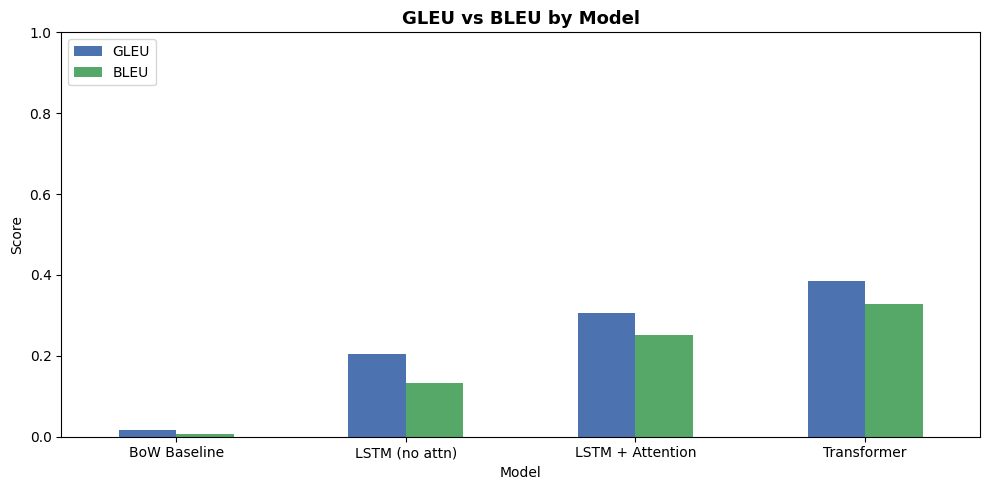

In [101]:
# ── 11.4  GLEU vs BLEU comparison plot ───────────────────────────────────────
compare_df = pd.DataFrame({
    'GLEU': {name: metrics['GLEU_mean'] for name, metrics in gleu_results.items()},
    'BLEU': {name: metrics['BLEU_mean'] for name, metrics in bleu_results.items()},
})

ax = compare_df.plot(kind='bar', figsize=(10, 5), color=['#4C72B0', '#55A868'])
ax.set_title('GLEU vs BLEU by Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
